In [1]:
# !pip install arviz
# !pip install numpyro
# !pip install jax
# !pip install scikit-learn

In [2]:
import arviz as az

In [3]:
from confdl import reformat_json, Vocabulary
import numpy as np

In [4]:
class Dataset:

    def __init__(self, j_data, rng=np.random.RandomState(23)):
        self.rng = rng
        self.Is = []
        self.Rs = []
        self.Ys = []
        self.items = Vocabulary()
        self.raters = Vocabulary()
        
        for i, j_rows in j_data.items():
            for rec in j_rows:
                iid = self.items(rec['id'])
                rid = self.raters(rec['rater'])
                y = rec['label']
                self.Is.append(iid)
                self.Rs.append(rid)
                self.Ys.append(y) 

    def get_mask(self, dropout_rates=None):
        mask = np.ones_like(self.Y)
        if dropout_rates is None:
            return mask
        for rater, drop_rate in dropout_rates.items():
            rid = self.raters(rater)
            coord = self.R == rid
            values = self.rng.uniform(0, 1, size=mask[coord].size) > drop_rate
            mask[coord] = values
        return mask
    
    @property
    def I(self):
        """
        The sequence of observed item ids
        shape [num_observations]
        """
        return np.array(self.Is)

    @property
    def R(self):
        """
        The sequence of observed rater ids
        shape [num_observations]
        """
        return np.array(self.Rs)
    
    @property
    def Y(self):
        """
        The sequence of observed labels
        shape [num_observations]
        """
        return np.array(self.Ys)

    @property
    def num_items(self):
        return len(self.items)

    @property
    def num_raters(self):
        return len(self.raters)

    @property
    def num_observations(self):
        return len(self.Y)

    def get_counts(self, raters=[]):
        rids = set()
        for rater in raters:
            if isinstance(rater, str):
                rid = self.raters(rater)
            else:
                rid = rater
            rids.add(rid)
        
        O0 = np.zeros(self.num_items)
        O1 = np.zeros(self.num_items)
        for i, r, y in zip(self.I, self.R, self.Y):
            if r in rids:
                if y:
                    O1[i] += 1
                else:
                    O0[i] += 1
        return O1, O0

In [5]:
import json
import numpy as np
import jax
import jax.numpy as jnp
import jax.scipy.special as jsp 
import jax.nn as jnn
import numpyro
import numpyro.distributions as dist

# The BDA model

An _item_ $i$ has an _unobserved_ true label $z_i$.

For each item, $\theta_i$ is the probability that $z_i=1$. This is a latent parameter, which we draw from a Beta prior:

$$\theta_i \sim \operatorname{Beta}(\alpha_\theta + o_{1,i}, \beta_\theta + o_{0,i})$$

with the Beta's parameters drawn from an appropriate prior. Optionally, if we have $N_i = o_{1,i} + o_{0,i}$ reliable observations of the items' labels $z_i$,  then by setting the statistics $o_{1,i}, o_{0,i}$ to the number of times the $i$th item was observed True (or False, respectively), we turn the Beta prior into a Beta posterior for a simple Beta-Binomial model.

Generally, we cannot observe $z_i$, but we can observe $y_{r,i}$ assigned by a labeller/rater $r$. Raters come in one of three kinds: oracles, annotators and quantifiers. For the BDA model these are different 'groups', and that's all. We put humans in the oracle group, automated NLG evaluation metrics in the annotators group and uncertainty quantifiers in the quantifiers group. 

## Concentration model

For each labeller $r$, we draw 1 concentration parameter from a Beta prior:
$$\kappa_r \sim \operatorname{Beta}(\alpha_r, \beta_r)$$

All labellers of a given kind $k_r$ (i.e., oracle/annotator/quantifier) share an appropriate prior over $\alpha_r, \beta_r$.

For the oracle, this prior is a strong U-shaped prior (this is to say we expect oracle raters to be confident when they label things as True or False). For the other groups, a weaker prior is appropriate, for example a flat Beta.

Finally, we observe the data:
$$y_{r,i} \sim \operatorname{Bernoulli}(\operatorname{sigmoid}(\kappa_r \times \operatorname{logit}(\theta_i) + b_r))$$

here we may optionally employ a rater-specific bias drawn from an appropriate prior such as 

$$b_r \sim \mathcal N(0, 2^2)$$

Note the parameter is obtained by scaling the item's logit, independently per rater. If the labels $y_{r,1},\ldots,y_{r,N}$ produced by rater $r$ correlate to $z_1, \ldots, z_N$, then $\kappa_r$ will tend to 1, otherwise $\kappa_r$ will tend to 0.

## Mixture model

For each labeller $r$, we draw two probabilities from a Beta prior:
* sensitivity $p_{1,r}$: the probability of observing $y_{r,i}=1$ when $z_i=1$
* specificity $p_{0,r}$: the probability of observing $y_{r,i}=0$ when $z_i=0$

All labellers of a given kind $k$ (i.e., oracle/annotator/quantifier) share a prior.

$$p_{1,r} \sim \operatorname{Beta}(\alpha_{k,1}, \beta_{k,1})$$

$$p_{0,r} \sim \operatorname{Beta}(\alpha_{k,0}, \beta_{k,0})$$

Finally, we observe the data

$$y_{r,i} \sim \operatorname{Bernoulli}(\theta_i \times p_{1,r} + (1-\theta_i)\times(1-p_{0,r}))$$

Note the parameter is the marginal probability $p(z_i=1)p(y_{r,i}=1|z_i=1) + p(z_i=0)p(y_{r,i}=1|z_i=0)$, where we marginalise the unobserved assignment of $z_i$.

**Remark.** If the concentration model's $\kappa_r$ is constrained to $(0,1)$, and the mixture model's $p_{1,r}$ is deterministically defined as $p_{0,r} = p_{1,r}$, then the two models are identical. We can then understand $\kappa_r$ as the probability of keeping the unobserved $z_i$ as is (i.e., not flipping it). 

## Uses

* Comparing judges: $i$ identifies a prompt-response pair, then $z_i$ captures whether the response is adequate to the prompt.
* Comparing uncertainty quantifiers: $i$ identifies a pair of prompt-response pairs, then $z_i$ captures the relative order of the pair. 


In [6]:
import matplotlib.pyplot as plt

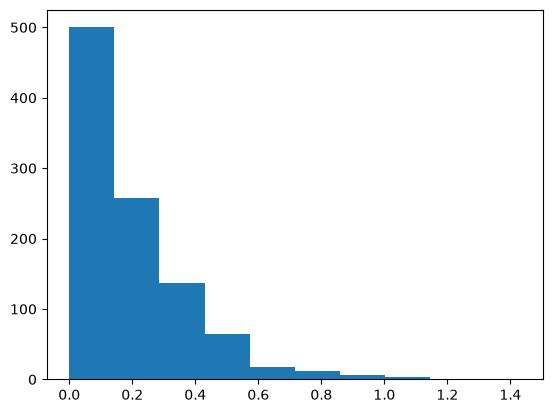

In [7]:
# _ = plt.hist(np.random.beta(0.9, 0.1, size=1000))
_ = plt.hist(dist.Exponential(5.0).sample(jax.random.PRNGKey(0), (1000,)))

In [8]:



def mixture_model(rater_idx, item_idx, oracle, num_items, num_raters, y_obs=None, mask=None, O1=0, O0=0, fix_oracle=True, 
                  item_prior=[1., 1.], oracle_prior=[0.5, 0.5], nonoracle_prior=[1., 1.]):
    """
    For readability, 
        M = num_observations
        N = num_items
        R = num_raters

    
    y_obs: (M,) observed ratings
    mask: (M,) 1 if observed
    rater_idx: (M,)
    item_idx: (M,)
    num_items: number of unique items
    raters: R strings of the kind O/oracle-alias, A/annotator-alias, Q/quantifier-alias
    O1: (N,) number of times each item was labelled True by a reliable source; use if available
    O0: (N,) number of times each item was labelled False by a reliable source; use if available
    fix_oracle: should oracle raters have a fixed parameter (i.e., 1)?
    item_prior: larger values (eg, [5., 5.] or [10., 10.]) will make the analysis more 'eagerly confident'
    oracle_prior: a sparse Beta prior is appropriate (eg, [0.5, 0.5]), since oracle annotators are usually reliable
    nonoracle_prior: a flat Beta prior is appropriate (eg, [1., 1.])
    """
    
    # Item prob's prior
    # []
    alpha_theta = numpyro.sample("alpha_theta", dist.Exponential(item_prior[0]))
    # []
    beta_theta  = numpyro.sample("beta_theta",  dist.Exponential(item_prior[1]))
    # alpha_theta, beta_theta = 0.1, 0.1

    with numpyro.plate("items", num_items):
        # Probability that z_i is True
        # [N]
        theta = numpyro.sample("theta", dist.Beta(alpha_theta + O1, beta_theta + O0))
 
    
    with numpyro.plate("raters", num_raters):   
        alpha_p1 = jnp.where(oracle, oracle_prior[0], nonoracle_prior[0])
        beta_p1 = jnp.where(oracle, oracle_prior[0], nonoracle_prior[0])

        alpha_p0 = jnp.where(oracle, oracle_prior[0], nonoracle_prior[0])
        beta_p0 = jnp.where(oracle, oracle_prior[0], nonoracle_prior[0])
        

        # P(y=1|z=1) "sensitivity"
        p1 = numpyro.sample("p1_", dist.Beta(alpha_p1, beta_p1))                
        
        # P(y=0|z=0) "specificity"
        p0 = numpyro.sample("p0_", dist.Beta(alpha_p0, beta_p0))
            
        if fix_oracle:
            p1 = jnp.where(oracle, jnp.ones_like(p1), p1)            
            p0 = jnp.where(oracle, jnp.ones_like(p0), p0)
            
        numpyro.deterministic("p1", p1)
        numpyro.deterministic("p0", p0)
        
    # Observation model
    theta_i = theta[item_idx]
    p1_r = p1[rater_idx]
    p0_r = p0[rater_idx]    
    # marginal prob of y[r,i] = 1
    phi_ir = numpyro.deterministic("phi_ir", theta_i * p1_r + (1 - theta_i)*(1 - p0_r))

    if mask is None:
        mask = jnp.ones(item_idx.size)
    numpyro.sample(
        "obs",
        dist.Bernoulli(phi_ir).mask(mask),
        obs=y_obs
    )


# The Data

In [9]:
experiment = 'trivia_qa_llama-8b-instruct_incl_human_judges'
input_file = f"data/{experiment}.json"
keep = {
    'human_judge1', 
    'human_judge2', 
    'llm_as_judge_gpt-5.4-mini', 
    # 'exact_match', 
    # 'rouge_l/0.1', 
    # 'bert_score/0.3', 
    'bert_score/0.8', 
    'bert_score/0.9', 
}
j_rows, s_rows = reformat_json(
    input_file,
    reverse={'entropy', 'semantic_entropy'},
    # shortening some names
    rename={'llm_as_judge_gpt-5.4-mini': 'gpt-5.4-mini', 'semantic_entropy': 'SE'},
    # analysing a subset of the data
    keep=keep,
)

In [10]:
data = Dataset(j_rows, rng=np.random.RandomState(42))

In [11]:
print(f"Analysing {data.num_items} items and {data.num_raters} raters")
for r, rater in enumerate(data.raters):
    print(f"\t{r}/{rater}")
print(f"items={data.I.shape} raters={data.R.shape} labels={data.Y.shape}")

Analysing 100 items and 5 raters
	0/human_judge1
	1/human_judge2
	2/bert_score/0.8
	3/bert_score/0.9
	4/gpt-5.4-mini
items=(500,) raters=(500,) labels=(500,)


In [12]:
# data.get_mask({'human_judge1': 0.5})

In [13]:
# data.get_counts({'human_judge1', 'human_judge2'})

In [14]:
import sklearn 
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

In [15]:
oracle = 'human_judge1'
for rater in data.raters:
    if rater == oracle:
        continue
    print(f"oracle={oracle} judge={rater}")
    print(classification_report(data.Y[data.R==data.raters(oracle)], data.Y[data.R==data.raters(rater)], zero_division=np.nan))    

oracle=human_judge1 judge=human_judge2
              precision    recall  f1-score   support

       False       0.96      0.90      0.93        29
        True       0.96      0.99      0.97        71

    accuracy                           0.96       100
   macro avg       0.96      0.94      0.95       100
weighted avg       0.96      0.96      0.96       100

oracle=human_judge1 judge=bert_score/0.8
              precision    recall  f1-score   support

       False       0.85      0.38      0.52        29
        True       0.79      0.97      0.87        71

    accuracy                           0.80       100
   macro avg       0.82      0.68      0.70       100
weighted avg       0.81      0.80      0.77       100

oracle=human_judge1 judge=bert_score/0.9
              precision    recall  f1-score   support

       False       0.30      1.00      0.46        29
        True       1.00      0.06      0.11        71

    accuracy                           0.33       100
   macr

# Inference

Inference via MCMC (specifically, NUTS)

In [16]:
from numpyro.infer import MCMC, NUTS
from jax import random

NUM_CHAINS = 2
numpyro.set_host_device_count(NUM_CHAINS)

In [17]:
kernel = NUTS(mixture_model)

mcmc = MCMC(
    kernel,
    num_warmup=1000,
    num_samples=2000,
    num_chains=NUM_CHAINS
)

/var/folders/5n/kqrxk4_d27342m7xqqjhg42c0000gn/T/ipykernel_54621/1620021319.py:3: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(


In [18]:
rng_key = random.PRNGKey(0)

# This is how you can gather the counts of labels assigned by a group of annotators
# (this is not something most users will need, but it's a helpful option for the analyst while developing BDA models
# O1, O0 = data.get_counts(['human_judge1', 'human_judge2'])

item_prior = [1., 1.]
oracle_prior = [0.5, 0.5]
nonoracle_prior = [1., 1.]

mcmc.run(
    rng_key,    
    rater_idx=data.R,
    item_idx=data.I,    
    oracle=np.array([rater.startswith('human_judge1') for rater in data.raters]),
    num_items=data.num_items,
    num_raters=data.num_raters,    
    y_obs=data.Y,  # use None for predictions and data.Y for posterior inference
    mask=None, # use None for predictions and data.get_mask() for posterior inference
    #you can drop observations like this (for example, to test the effect of data size)
    #mask=data.get_mask({'human_judge1': 0, 'human_judge2': 0}),
    fix_oracle=True, # you will want to set this to True, unless you have counts available for O1 and O0 below
    # use these to play with item-level posteriors as priors
    # O1=O1,
    # O0=O0,
    item_prior=item_prior,
    oracle_prior=oracle_prior,
    nonoracle_prior=nonoracle_prior,
)

sample: 100%|█| 3000/3000 [00:03<00:00, 805.23it/s, 31 steps of size 1.77e-01. acc. pro
sample: 100%|█| 3000/3000 [00:04<00:00, 746.73it/s, 31 steps of size 1.25e-01. acc. pro


Ideally: `r_hat` is close to 1 and we have 0 divergences.

In [19]:
mcmc.print_summary()


                   mean       std    median      5.0%     95.0%     n_eff     r_hat
  alpha_theta      0.41      0.10      0.40      0.25      0.57    777.69      1.00
   beta_theta      0.19      0.03      0.18      0.13      0.24    886.08      1.00
       p0_[0]      0.50      0.36      0.50      0.00      0.97   4885.69      1.00
       p0_[1]      0.95      0.04      0.96      0.89      1.00   4531.27      1.00
       p0_[2]      0.44      0.10      0.44      0.28      0.62   3690.36      1.00
       p0_[3]      0.96      0.04      0.97      0.91      1.00   5111.93      1.00
       p0_[4]      0.90      0.07      0.91      0.80      1.00   2995.97      1.00
       p1_[0]      0.50      0.35      0.49      0.00      0.97   4633.09      1.00
       p1_[1]      0.98      0.02      0.99      0.96      1.00   4986.87      1.00
       p1_[2]      0.97      0.02      0.98      0.94      1.00   3093.99      1.00
       p1_[3]      0.07      0.03      0.06      0.02      0.11   3910.72  

In [20]:
idata = az.from_numpyro(
    mcmc,
    dims={
        'alpha_theta': [],
        'beta_theta': [],
        'p0_': ['raters'],
        'p0': ['raters'],
        'p1_': ['raters'],
        'p1': ['raters'],
        'theta': ['items'],
    },
    coords={
        "raters": data.raters, #np.arange(len(data.raters)),
        "items": np.arange(len(data.items)),
    }   
)

These are the infered parameters

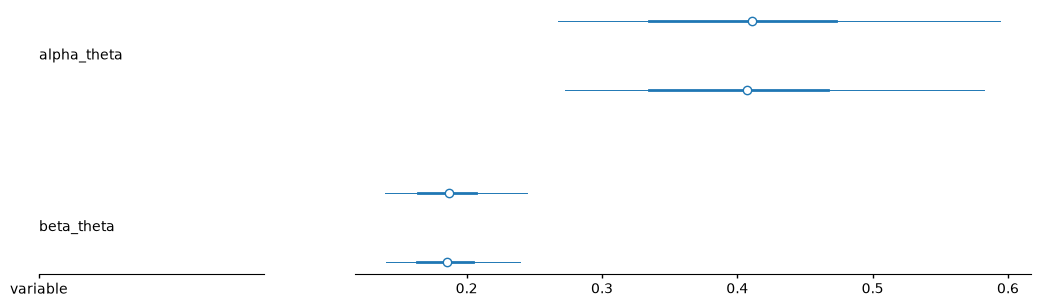

In [21]:
az.plot_forest(
    idata, 
    var_names=['alpha_theta', 'beta_theta'],
)

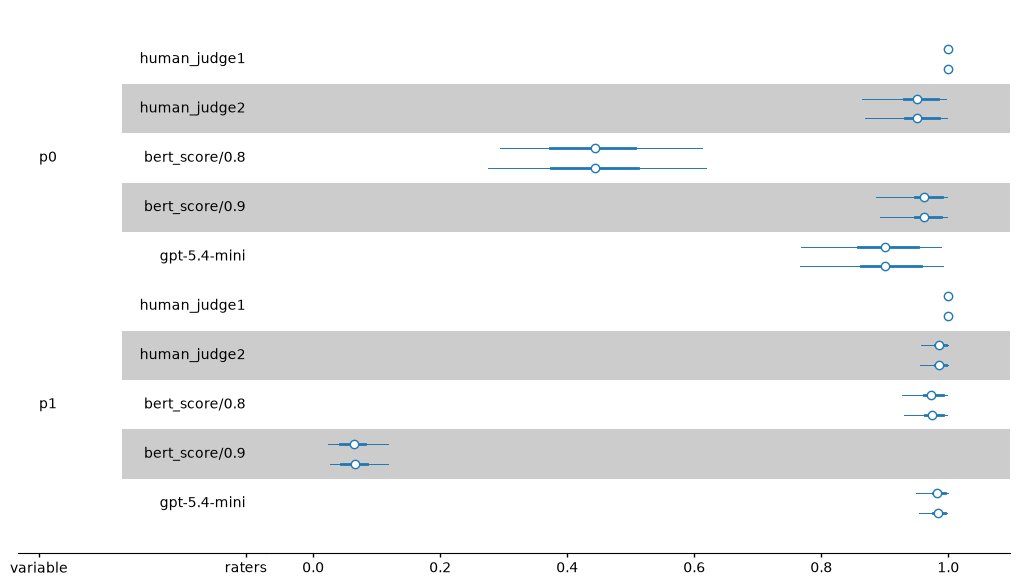

In [22]:
az.plot_forest(
    idata, 
    var_names=['p0', 'p1'],
    shade_label="raters",
)

Gather posterior samples and plot relevant stuff

In [23]:
posterior_samples = mcmc.get_samples(group_by_chain=False)
print("posterior samples shapes:")
for k, v in posterior_samples.items():
    print(k, v.shape)

posterior samples shapes:
alpha_theta (4000,)
beta_theta (4000,)
p0 (4000, 5)
p0_ (4000, 5)
p1 (4000, 5)
p1_ (4000, 5)
phi_ir (4000, 500)
theta (4000, 100)


A rather basic posterior predictive check is to attempt to "reconstruct" the data

In [24]:
from numpyro.infer import Predictive
# Use Predictive to compute the 'effect_size' site for all posterior draws
predictive = Predictive(mixture_model, posterior_samples)
samples = predictive(
    random.PRNGKey(1),     
    rater_idx=data.R,
    item_idx=data.I,    
    oracle=np.array([rater.startswith('human_judge1') for rater in data.raters]),
    num_items=data.num_items,
    num_raters=data.num_raters,
    y_obs=None,
    mask=None,
    fix_oracle=True,
    item_prior=item_prior,
    oracle_prior=oracle_prior,
    nonoracle_prior=nonoracle_prior,
)

Here I plot the distribution of accuracies

human_judge1 0.89804494 0.029113194
human_judge2 0.89113253 0.034816556
bert_score/0.8 0.8172376 0.03586981
bert_score/0.9 0.90766007 0.030791631
gpt-5.4-mini 0.8659301 0.035667706


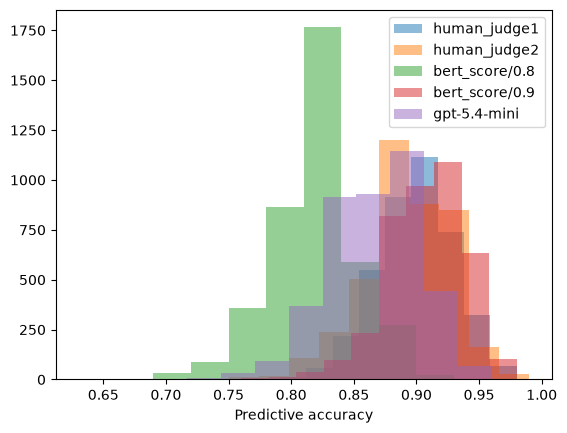

In [25]:
for rname, rid in data.raters.items():
    predaccs = (samples['obs'][:,data.R==rid] == data.Y[data.R==rid]).mean(-1)
    _ = plt.hist(predaccs, label=rname, alpha=0.5)
    print(rname, predaccs.mean(), predaccs.std())
    _ = plt.xlabel("Predictive accuracy")
_ = plt.legend()
    

# Analysis

It's convenient to analyse expected accuracy and expected F1 (as they are more directly interpretable/useful than the model's latent parameters).

In [26]:
def posterior_inferences(samples):

    inferences = dict()
    
    # theta needs to go from [S, N] to [S, 1, N]
    # p  needs to go from [S, R] to [S, R, 1]
    # so their product has shape [S, R, N]
    
    # [S, R, N]
    # P(z=1,y=1)
    TP = samples['theta'][:,None,:] * samples['p1'][:,:,None]
    # [S, R, N]
    # P(z=0,y=)
    TN = (1-samples['theta'][:,None,:])*samples['p0'][:,:,None]

    # [S, R, N]
    # P(z=1,y=0)
    FN = samples['theta'][:,None,:] * (1-samples['p1'][:,:,None])
    # [S, R, N]
    # P(z=0,y=1)
    FP = (1-samples['theta'][:,None,:]) * (1-samples['p0'][:,:,None])
    
    # [S, R]
    inferences['p0'] = samples['p0']
    inferences['p1'] = samples['p1']
    inferences['TP'] = jnp.mean(TP, -1)
    inferences['TN'] = jnp.mean(TN, -1)
    inferences['FN'] = jnp.mean(FN, -1)
    inferences['FP'] = jnp.mean(FP, -1)
    inferences['acc'] = jnp.mean(TP + TN, -1)
    inferences['err'] = jnp.mean(FP + FN, -1)
    inferences['F1'] = jnp.mean(2*TP / (2*TP + FP + FN), -1)
    inferences['MCC'] = jnp.mean((TP*TN - FP*FN)/(jnp.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))), -1)

    return inferences


In [27]:
inf = posterior_inferences(posterior_samples)

In [28]:
inf['p0'].shape, inf['TP'].shape, inf.keys()

((4000, 5),
 (4000, 5),
 dict_keys(['p0', 'p1', 'TP', 'TN', 'FN', 'FP', 'acc', 'err', 'F1', 'MCC']))

In [29]:
infdata = az.from_dict(
    {
        'posterior': {k: v.reshape(2, -1, len(data.raters))for k, v in inf.items()}
    },
    dims={
        'p0': ['raters'],
        'p1': ['raters'],
        'TP': ['raters'],
        'TN': ['raters'],
        'FN': ['raters'],
        'FP': ['raters'],
        'acc': ['raters'],
        'err': ['raters'],
        'F1': ['raters'],
        'MCC': ['raters'],
    },
    coords={
        "raters": data.raters,
    },    
)

In [30]:
# import matplotlib as mpl
# mpl.rcParams["axes.grid"] = True
# mpl.rcParams["axes.grid.axis"] = "x"   # only vertical lines
# mpl.rcParams["grid.linestyle"] = "--"
# mpl.rcParams["grid.alpha"] = 0.3

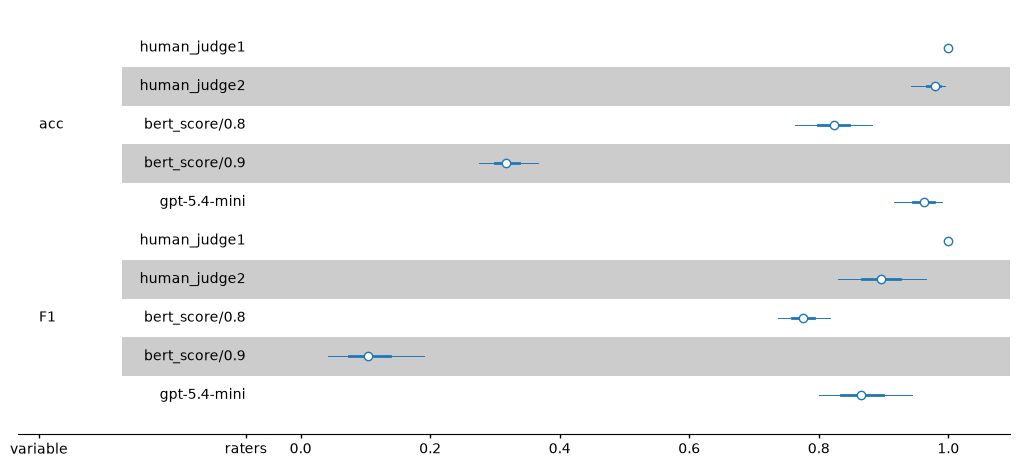

In [31]:
az.plot_forest(
    infdata, 
    var_names=['acc', 'F1'],
    shade_label="raters",
    combined=True,
    point_estimate="median",
)

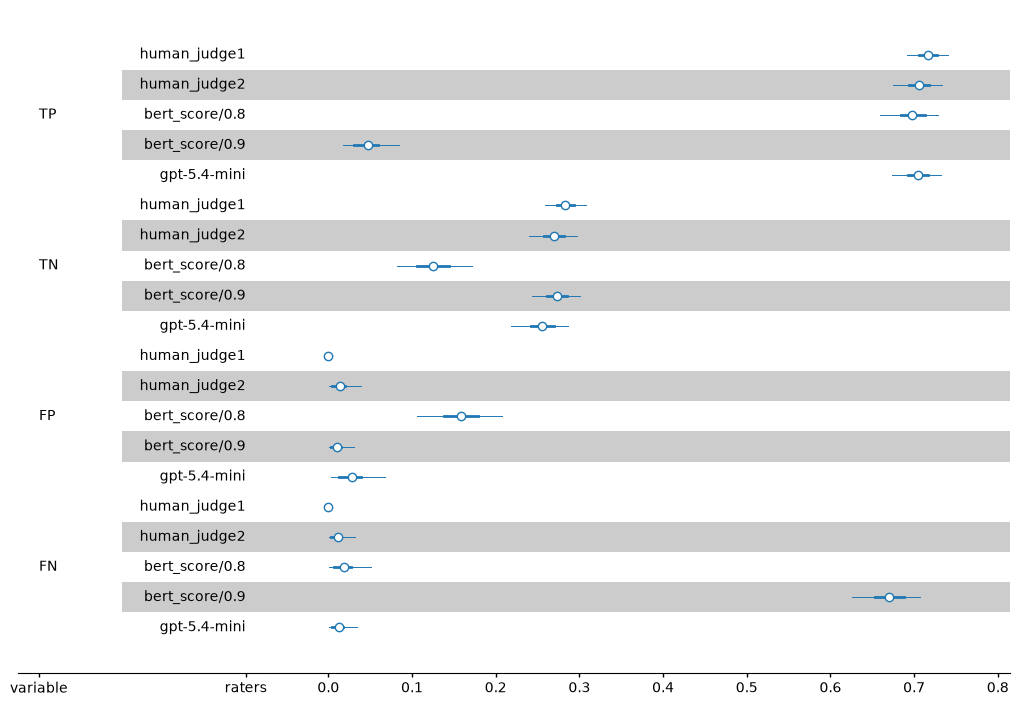

In [32]:
az.plot_forest(
    infdata, 
    var_names=['TP', 'TN', 'FP', 'FN'],
    shade_label="raters",
    combined=True,
)

# Other, older plotting tools

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def raterstats2df(inf, raters):
    rows = []
    for key, array in inf.items():
        for r, rater in enumerate(raters):
            for v in array[:,r]:
                rows.append([key, rater, float(v)])
    return pd.DataFrame(rows, columns=['stat', 'rater', 'value'])

# def make_df(samples, a="key", b="value"):
#     rows = []
#     for param, values in samples.items():
#         values = np.ravel(values)
#         for v in values:
#             rows.append({a: param, b: v})
    
#     return pd.DataFrame(rows)

In [34]:
df_raters = raterstats2df(inf, data.raters)
# df_raters

In [35]:
# for key, value in other.items():
#     _ = plt.hist(value, label=key, alpha=0.5)
# _ = plt.legend()

In [36]:
# df_plot = df_raters[df_raters["stat"].eq("acc")]
# uqs = [rater for rater in data.raters if rater.startswith('A/gpt') or rater.startswith('A/rougel-1') or rater.startswith('A/llama') or rater.startswith('O/')]
uqs = data.raters

<Axes: xlabel='value', ylabel='rater'>

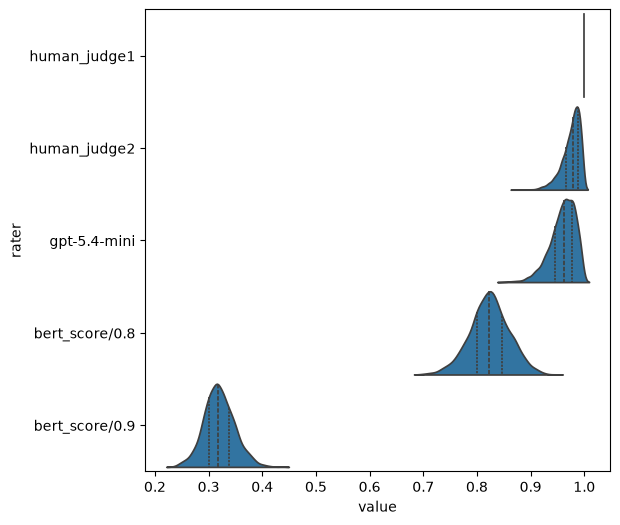

In [37]:
plt.figure(figsize=(6, 6))
showing = 'acc'
sns.violinplot(
    df_raters[df_raters['rater'].isin(uqs)][df_raters['stat'].eq(showing)], y="rater", x="value", 
    split=True, inner="quart", fill=True, 
    width=0.9,
    density_norm="width",
    order=list(reversed(
        df_raters[df_raters['rater'].isin(uqs)][df_raters['stat'].eq(showing)].groupby("rater")["value"]
        .mean()
        .sort_values()
        .index
    ))
)

In [38]:
# plt.figure(figsize=(6, 12))
# df_main = df_raters[df_raters['rater'].isin(uqs)][df_raters["stat"].eq("acc")]

# order = list(reversed(
#     df_main.groupby("rater")["value"]
#     .mean()
#     .sort_values()
#     .index
# ))

# sns.violinplot(
#     #[~df_raters['rater'].isin({'O/human1', 'O/human2'})]
#     # df_raters[df_raters['rater'].isin(uqs)][df_raters['stat'].isin(['acc-diff'])],     
#     df_raters[df_raters['rater'].isin(uqs)][df_raters["stat"].isin(["acc-diff-1", "acc-diff-3",])],
#     hue="stat",
#     y="rater", x="value", 
#     split=True, inner="quart", fill=True, 
#     width=0.9,
#     order=order,
#     density_norm="width"
# )

<Axes: xlabel='value', ylabel='rater'>

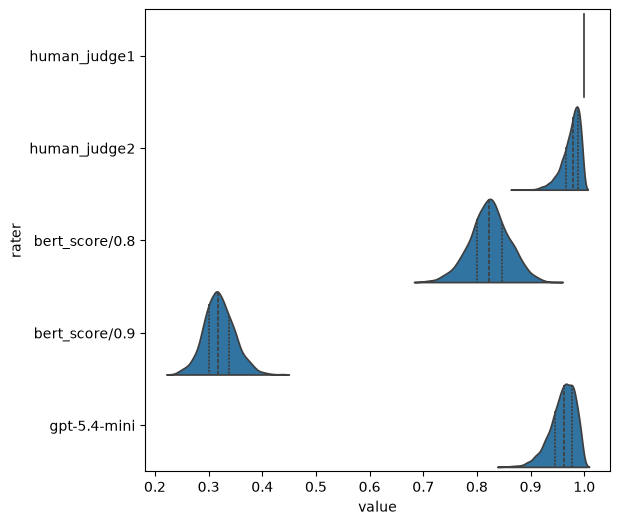

In [39]:
plt.figure(figsize=(6, 6))
sns.violinplot(
    df_raters[~df_raters['rater'].isin({'human_judge'})][df_raters['stat'].eq('acc')], y="rater", x="value", 
    split=True, inner="quart", fill=True, 
    width=0.9,
    density_norm="width"
)

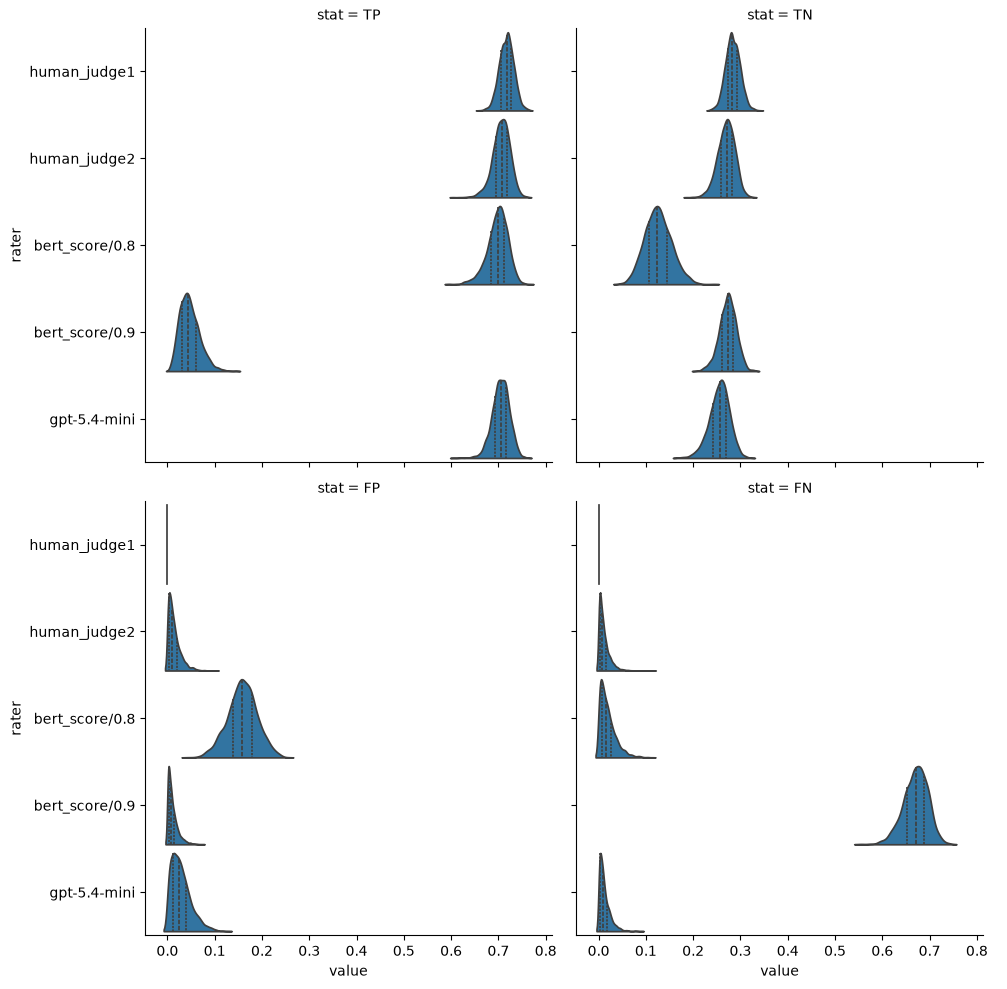

In [40]:
sns.catplot(
    df_raters,
    y="rater",
    x="value",
    col="stat",
    col_wrap=2,
    col_order=["TP", "TN", "FP", "FN"],
    kind="violin", 
    
    split=True, inner="quart", fill=True, 
    width=0.9,
    density_norm="width"
)

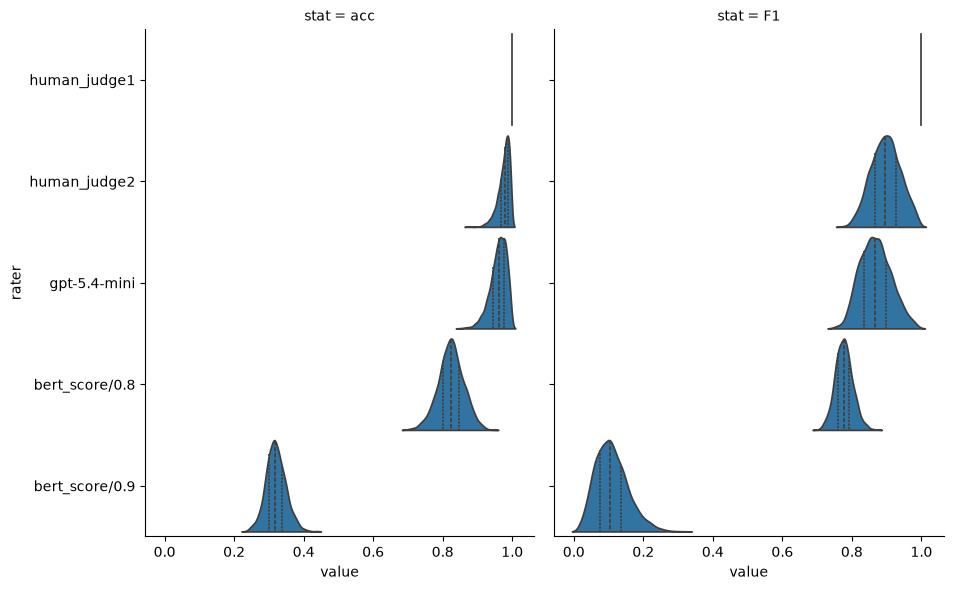

In [41]:
df_main = df_raters[df_raters["stat"].eq("F1")]

order = list(reversed(
    df_raters.groupby("rater")["value"]
    .mean()
    .sort_values()
    .index
))


sns.catplot(
    # df_raters[~df_raters['rater'].isin({'human_judge1', 'human_judge2'})],
    df_raters,
    y="rater",
    x="value",
    # hue="stat",
    # hue_order=["acc", "F1"],
    col="stat",
    col_wrap=2,
    col_order=["acc", "F1"],
    kind="violin",
    order=order,
    split=True, inner="quart", fill=True, 
    width=0.9,
    density_norm="width",
    height=6,
    aspect=0.8
)

In [42]:
# sns.catplot(
#     df_raters[df_raters['stat'].isin({'p1', 'p0'})][~df_raters['rater'].isin({'O/human1', 'O/human2'})],
#     y="rater",
#     x="value",
#     hue="stat",
#     hue_order=["p1", "p0"],
#     kind="violin", 
    
#     split=True, inner="quart", fill=True, 
#     width=0.9,
#     density_norm="width"
# )

(array([ 63033.,  17256.,  11490.,   8664.,   7926.,   8226.,  10409.,
         15233.,  27476., 230287.]),
 array([1.55503073e-20, 9.99999866e-02, 1.99999973e-01, 2.99999952e-01,
        3.99999946e-01, 4.99999940e-01, 5.99999905e-01, 6.99999928e-01,
        7.99999893e-01, 8.99999857e-01, 9.99999881e-01]),
 <BarContainer object of 10 artists>)

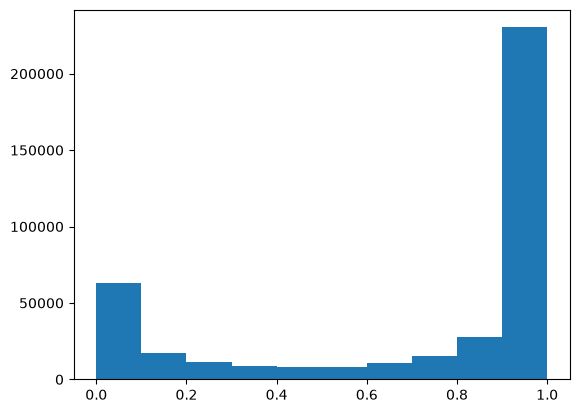

In [43]:
plt.hist(posterior_samples['theta'].flatten())